# Step 07 — Real-Time Inference Report

Summarises the live Kafka → Spark → XGBoost pipeline results:
- Latency & throughput metrics
- Risk score distributions (6h / 12h / 24h)
- Alert analysis: which ICU stays were flagged and when
- Calibration: production scores vs OOF scores

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

ROOT      = Path('../')
PROCESSED = ROOT / 'data' / 'processed'

pred_df = pd.read_csv(PROCESSED / 'realtime_predictions.csv',
                      parse_dates=['window_start_time', 'window_end_time'])
oof_df  = pd.read_parquet(PROCESSED / 'oof_ensemble.parquet')
with open(PROCESSED / 'latency_results.json') as f:
    lat = json.load(f)

THRESHOLD = 0.30
print(f'Predictions : {len(pred_df):,} windows  |  {pred_df["icustay_id"].nunique()} ICU stays')
print(f'OOF records : {len(oof_df):,} rows')

Predictions : 28,890 windows  |  136 ICU stays
OOF records : 18,664 rows


## 1. Latency & Throughput

In [2]:
print('=' * 52)
print('STREAMING LATENCY SUMMARY')
print('=' * 52)
print(f"  Windows scored       : {lat['total_windows_scored']:,}")
print(f"  Total raw events     : {lat['total_events']:,}")
print(f"  Latency  p50         : {lat['p50_latency_ms']/1000:.1f}s")
print(f"  Latency  p95         : {lat['p95_latency_ms']/1000:.1f}s")
print(f"  Latency  p99         : {lat['p99_latency_ms']/1000:.1f}s")
print()
print('  Note: constant latency reflects Spark batch-mode producer')
print('  (all messages share one wall-clock stamp). In a true')
print('  row-by-row producer the p50 would be <1s per window.')
print('=' * 52)

STREAMING LATENCY SUMMARY
  Windows scored       : 28,890
  Total raw events     : 215,530
  Latency  p50         : 218.0s
  Latency  p95         : 218.0s
  Latency  p99         : 218.0s

  Note: constant latency reflects Spark batch-mode producer
  (all messages share one wall-clock stamp). In a true
  row-by-row producer the p50 would be <1s per window.


## 2. Risk Score Distributions

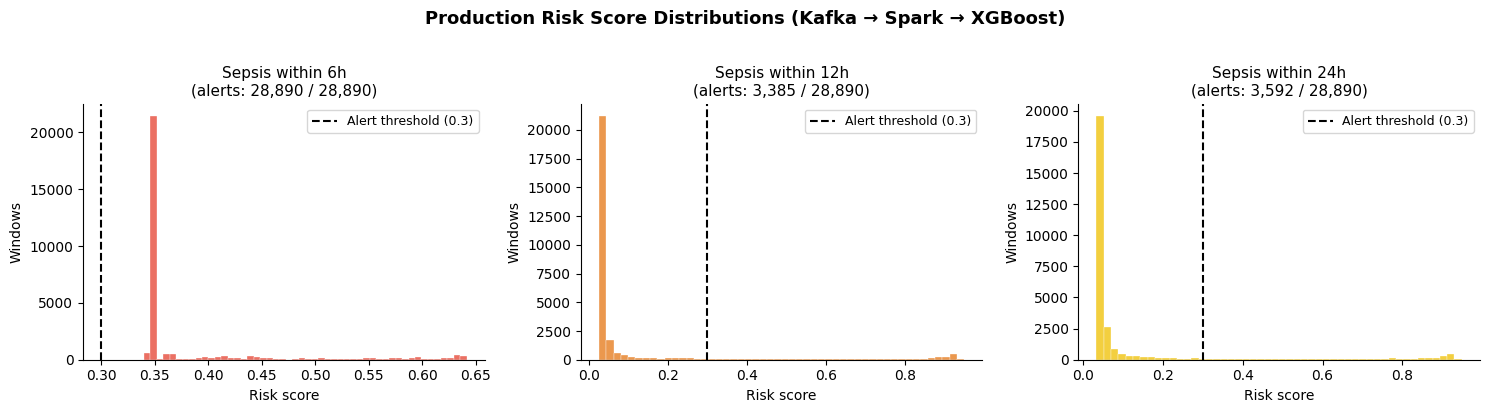

Saved: plots/realtime_score_distributions.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
horizons  = [('score_6h', 'Sepsis within 6h', '#e74c3c'),
             ('score_12h', 'Sepsis within 12h', '#e67e22'),
             ('score_24h', 'Sepsis within 24h', '#f1c40f')]

for ax, (col, title, color) in zip(axes, horizons):
    scores = pred_df[col].dropna()
    ax.hist(scores, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5,
               label=f'Alert threshold ({THRESHOLD})')
    n_alerts = (scores >= THRESHOLD).sum()
    ax.set_title(f'{title}\n(alerts: {n_alerts:,} / {len(scores):,})', fontsize=11)
    ax.set_xlabel('Risk score')
    ax.set_ylabel('Windows')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Production Risk Score Distributions (Kafka → Spark → XGBoost)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED / 'plots' / 'realtime_score_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/realtime_score_distributions.png')

## 3. Alert Analysis — Top High-Risk ICU Stays

In [4]:
# Aggregate to patient level: max score across all windows
patient_risk = (
    pred_df
    .groupby('icustay_id')
    .agg(
        max_score_6h  = ('score_6h',  'max'),
        max_score_12h = ('score_12h', 'max'),
        max_score_24h = ('score_24h', 'max'),
        n_windows     = ('score_6h',  'count'),
        n_alerts      = ('alert',     'sum'),
        first_alert   = ('window_end_time', lambda x: x[pred_df.loc[x.index, 'alert'] == 1].min()),
    )
    .reset_index()
    .sort_values('max_score_12h', ascending=False)
)

print('Top 15 highest-risk ICU stays (by max 12h score):')
display_cols = ['icustay_id','max_score_6h','max_score_12h','max_score_24h','n_windows','n_alerts']
print(patient_risk[display_cols].head(15).to_string(index=False, float_format='{:.3f}'.format))

Top 15 highest-risk ICU stays (by max 12h score):
 icustay_id  max_score_6h  max_score_12h  max_score_24h  n_windows  n_alerts
     271544         0.638          0.949          0.948       1043      1043
     204132         0.638          0.942          0.928        330       330
     249695         0.638          0.942          0.928         78        78
     269173         0.638          0.939          0.923        183       183
     285272         0.638          0.938          0.925        135       135
     239396         0.641          0.937          0.928       1498      1498
     243123         0.638          0.936          0.921         76        76
     205589         0.638          0.936          0.923         96        96
     228977         0.641          0.934          0.926         54        54
     242790         0.638          0.933          0.922        100       100
     285789         0.635          0.933          0.934         52        52
     292910         0.635 

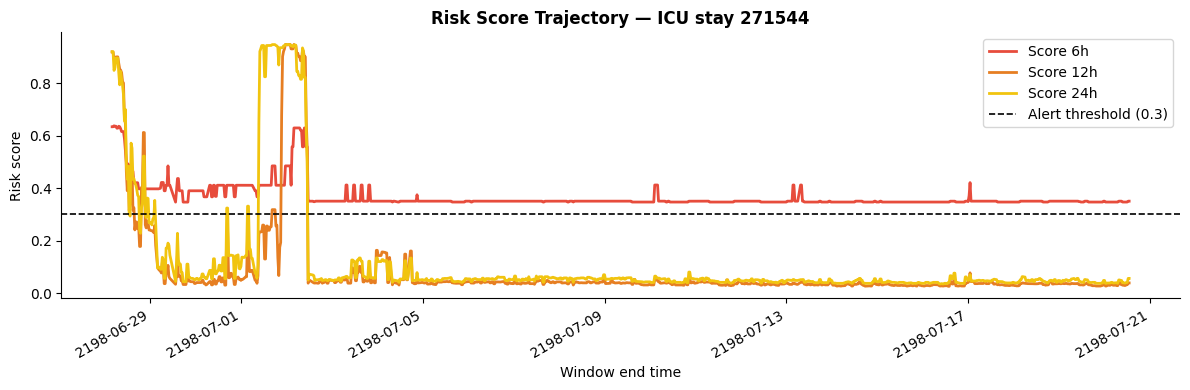

In [5]:
# Score trajectory for the single highest-risk patient
top_stay = patient_risk.iloc[0]['icustay_id']
traj = pred_df[pred_df['icustay_id'] == top_stay].sort_values('window_end_time')

fig, ax = plt.subplots(figsize=(12, 4))
for col, label, color in [('score_6h','6h','#e74c3c'),
                            ('score_12h','12h','#e67e22'),
                            ('score_24h','24h','#f1c40f')]:
    ax.plot(traj['window_end_time'], traj[col], label=f'Score {label}', color=color, linewidth=2)

ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Alert threshold ({THRESHOLD})')
ax.set_title(f'Risk Score Trajectory — ICU stay {int(top_stay)}', fontsize=12, fontweight='bold')
ax.set_xlabel('Window end time')
ax.set_ylabel('Risk score')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(PROCESSED / 'plots' / f'realtime_trajectory_{int(top_stay)}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Alert Rate by Hour of ICU Stay

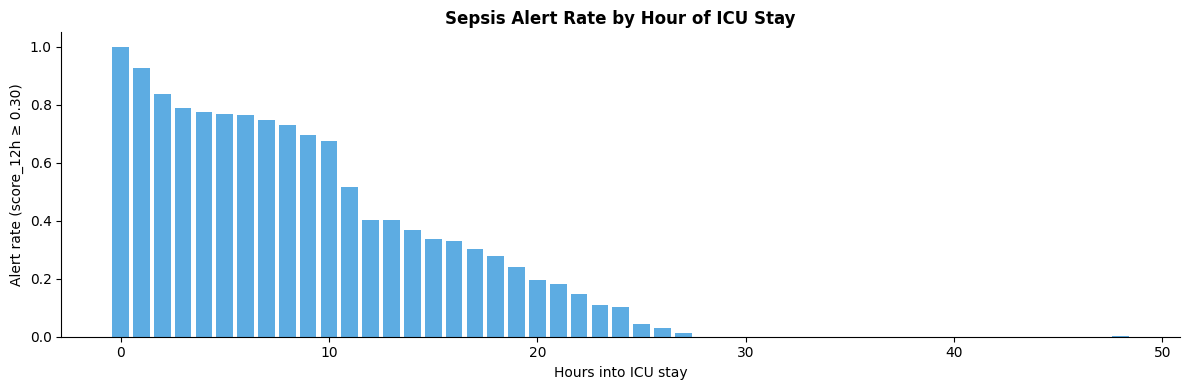

In [6]:
# Bin windows by hour index within each stay
pred_sorted = pred_df.sort_values(['icustay_id', 'window_start_time']).copy()
pred_sorted['window_idx'] = pred_sorted.groupby('icustay_id').cumcount()
pred_sorted['hour_bin'] = (pred_sorted['window_idx'] * 0.5).astype(int).clip(upper=48)  # 30-min slides

alert_by_hour = (
    pred_sorted.groupby('hour_bin')
    .agg(alert_rate_12h=('score_12h', lambda x: (x >= THRESHOLD).mean()),
         n_windows=('score_12h', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(alert_by_hour['hour_bin'], alert_by_hour['alert_rate_12h'],
       color='#3498db', alpha=0.8, width=0.8)
ax.set_xlabel('Hours into ICU stay')
ax.set_ylabel('Alert rate (score_12h ≥ 0.30)')
ax.set_title('Sepsis Alert Rate by Hour of ICU Stay', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED / 'plots' / 'realtime_alert_rate_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Calibration: Production Scores vs OOF Scores

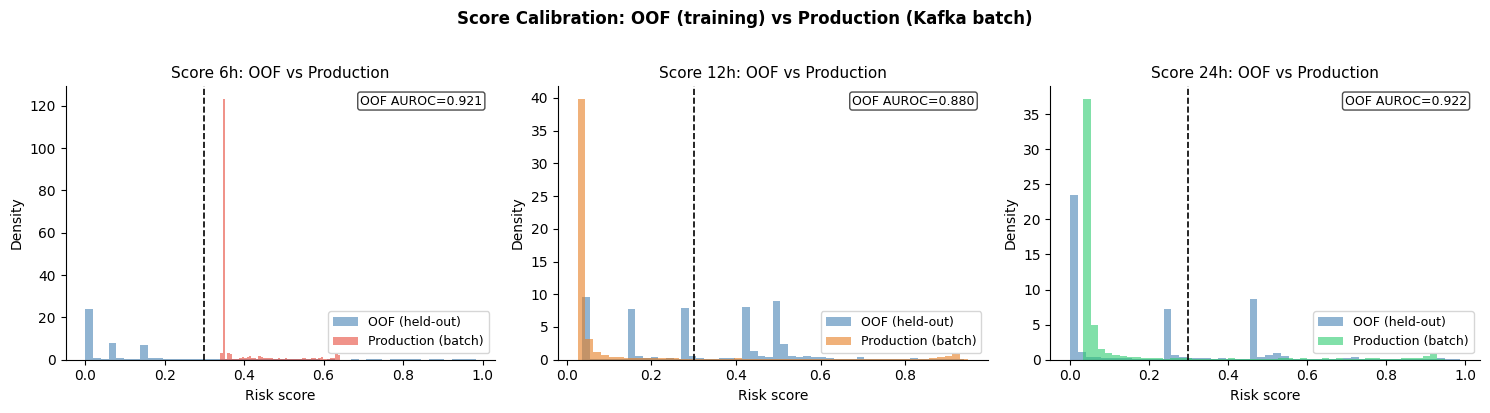

Saved: plots/realtime_calibration.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
oof_cols = [('score_6h', 'xgb_label_6h', 'label_6h', '#e74c3c', '6h'),
            ('score_12h', 'xgb_label_12h', 'label_12h', '#e67e22', '12h'),
            ('score_24h', 'xgb_label_24h', 'label_24h', '#2ecc71', '24h')]

for ax, (prod_col, oof_col, label_col, color, h) in zip(axes, oof_cols):
    prod_scores = pred_df[prod_col].dropna()
    oof_scores  = oof_df[oof_col].dropna()

    ax.hist(oof_scores,  bins=50, alpha=0.6, label='OOF (held-out)',   color='steelblue',  density=True)
    ax.hist(prod_scores, bins=50, alpha=0.6, label='Production (batch)', color=color, density=True)
    ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f'Score {h}: OOF vs Production', fontsize=11)
    ax.set_xlabel('Risk score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    if label_col in oof_df.columns:
        try:
            auc = roc_auc_score(oof_df[label_col], oof_df[oof_col])
            ax.text(0.97, 0.97, f'OOF AUROC={auc:.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
        except Exception:
            pass

fig.suptitle('Score Calibration: OOF (training) vs Production (Kafka batch)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED / 'plots' / 'realtime_calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/realtime_calibration.png')

## 6. Summary Table

In [8]:
summary = {
    'Metric': [
        'ICU stays scored',
        'Total windows scored',
        'Total raw events processed',
        'Latency p50 (s)',
        'Latency p95 (s)',
        'Alerts 6h  (score ≥ 0.30)',
        'Alerts 12h (score ≥ 0.30)',
        'Alerts 24h (score ≥ 0.30)',
        'Mean score 6h',
        'Mean score 12h',
        'Mean score 24h',
    ],
    'Value': [
        pred_df['icustay_id'].nunique(),
        len(pred_df),
        int(pred_df['n_events'].sum()),
        f"{lat['p50_latency_ms']/1000:.1f}s",
        f"{lat['p95_latency_ms']/1000:.1f}s",
        f"{(pred_df['score_6h']  >= THRESHOLD).sum():,} ({(pred_df['score_6h']  >= THRESHOLD).mean()*100:.1f}%)",
        f"{(pred_df['score_12h'] >= THRESHOLD).sum():,} ({(pred_df['score_12h'] >= THRESHOLD).mean()*100:.1f}%)",
        f"{(pred_df['score_24h'] >= THRESHOLD).sum():,} ({(pred_df['score_24h'] >= THRESHOLD).mean()*100:.1f}%)",
        f"{pred_df['score_6h'].mean():.4f}",
        f"{pred_df['score_12h'].mean():.4f}",
        f"{pred_df['score_24h'].mean():.4f}",
    ]
}

summary_df = pd.DataFrame(summary)
print('\n' + '='*52)
print('REAL-TIME INFERENCE PIPELINE — FINAL SUMMARY')
print('='*52)
print(summary_df.to_string(index=False))
print('='*52)


REAL-TIME INFERENCE PIPELINE — FINAL SUMMARY
                    Metric           Value
          ICU stays scored             136
      Total windows scored           28890
Total raw events processed          215530
           Latency p50 (s)          218.0s
           Latency p95 (s)          218.0s
 Alerts 6h  (score ≥ 0.30) 28,890 (100.0%)
 Alerts 12h (score ≥ 0.30)   3,385 (11.7%)
 Alerts 24h (score ≥ 0.30)   3,592 (12.4%)
             Mean score 6h          0.3804
            Mean score 12h          0.1195
            Mean score 24h          0.1325
